# 05d Saved 05a Models - Dataset 1 and Dataset 2

Simple experiment using the models saved from notebook 05a.

- Dataset 1: keep the same temporal split structure as 05a and retrain the saved model pipeline on each dataset.
- Dataset 2: run two experiments: retrain on a random split, and direct prediction using the saved 05a model without retraining.

In [17]:
from pathlib import Path
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.base import clone
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

def find_project_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for path in [start, *start.parents]:
        if (path / 'src').exists() and (path / 'requirements.txt').exists():
            return path
    raise FileNotFoundError('Project root not found.')


PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT))
from src.models.ml_train_and_store import load_model, top1_bank_cohort, top1_metrics

PROJECT_ROOT = find_project_root()
EMB_DIR = PROJECT_ROOT / 'src' / 'data' / 'embeddings'
MODEL_DIR = PROJECT_ROOT / 'src' / 'models' / 'train_saved' / '05_a'
OUT_DIR = PROJECT_ROOT / 'src' / 'data' / 'predictions' / '05d_saved_05a'
OUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_COL = 'log_systemic_risk_label'
RANDOM_STATE = 42
TARGET_DISTRIBUTION_BINS = 10
ROUND_DECIMALS = 3
TRAIN_END_YEAR = 2021
TRAIN_END_QUARTER = 4
METRIC_COLUMNS = [
    'train_rmse', 'validation_rmse',
    'train_mae', 'validation_mae',
    'train_top1_rmse', 'validation_top1_rmse',
    'train_top1_mae', 'validation_top1_mae',
]

pd.set_option('display.max_columns', 120)
print(PROJECT_ROOT)

C:\Users\ruben\Desktop\Universidade\Nova IMS\Tese\Thesis


## Inputs

In [18]:
P_LABELS = ['p5', 'p10', 'p15', 'p20', 'p25', 'p30', 'p35', 'p40']

dataset1_files = {
    'dataset1_baseline': 'graphsage_v1_32_srisk_dataset.parquet',
    **{f'dataset1_{p}': f'graphsage_v1_32_{p}_dataset.parquet' for p in P_LABELS},
}

dataset2_files = {
    'dataset2_baseline': 'graphsage_v1_32_dataset2_dataset.parquet',
    **{f'dataset2_{p}': f'graphsage_v1_32_dataset2_{p}_dataset.parquet' for p in P_LABELS},
}

models = {
    path.stem.replace('_', ' '): load_model(path)
    for path in sorted(MODEL_DIR.glob('*.joblib'))
    if 'MLP' in path.stem
}

if not models:
    raise FileNotFoundError(f'No saved models found in {MODEL_DIR}')

print('Models:', list(models))
print('Dataset 1 files:', len(dataset1_files))
print('Dataset 2 files:', len(dataset2_files))

Models: ['MLP (tuned)']
Dataset 1 files: 9
Dataset 2 files: 9


## Helpers

In [19]:
def load_dataset(filename):
    df = pd.read_parquet(EMB_DIR / filename).copy()
    feature_cols = [c for c in df.columns if c.startswith('emb_')]
    df = df.dropna(subset=[TARGET_COL]).reset_index(drop=True)
    return df, feature_cols


def temporal_split(df):
    keyed = df.copy()
    keyed['_key'] = keyed['year'] * 10 + keyed['quarter']

    train_df = keyed[keyed['_key'] <= 20214].drop(columns='_key')
    val_df = keyed[(keyed['_key'] > 20214) & (keyed['_key'] <= 20224)].drop(columns='_key')
    test_df = keyed[(keyed['_key'] > 20224) & (keyed['_key'] <= 20233)].drop(columns='_key')

    return train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)


def make_stratify_bins(df, max_bins=TARGET_DISTRIBUTION_BINS):
    y = df[TARGET_COL]
    max_bins = min(max_bins, y.nunique())

    for n_bins in range(max_bins, 1, -1):
        try:
            bins = pd.qcut(y, q=n_bins, labels=False, duplicates='drop')
        except ValueError:
            continue

        counts = pd.Series(bins).value_counts()
        if len(counts) > 1 and counts.min() >= 2:
            return bins

    return None


def random_split(df):
    stratify_bins = make_stratify_bins(df)
    train_val_df, test_df = train_test_split(
        df,
        test_size=0.15,
        random_state=RANDOM_STATE,
        shuffle=True,
        stratify=stratify_bins,
    )

    val_stratify_bins = make_stratify_bins(train_val_df)
    train_df, val_df = train_test_split(
        train_val_df,
        test_size=0.15 / 0.85,
        random_state=RANDOM_STATE,
        shuffle=True,
        stratify=val_stratify_bins,
    )

    return train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)


def metrics(y_true, y_pred):
    return {
        'mae': mean_absolute_error(y_true, y_pred),
        'rmse': mean_squared_error(y_true, y_pred) ** 0.5,
    }


def add_predictions(dataset_name, experiment, model_name, split_name, split_df, model, feature_cols):
    id_cols = [c for c in ['bank_id', 'year', 'quarter', 'period'] if c in split_df.columns]
    pred_df = split_df[id_cols + [TARGET_COL]].copy()
    pred_df['prediction'] = model.predict(split_df[feature_cols])
    pred_df['abs_error'] = (pred_df[TARGET_COL] - pred_df['prediction']).abs()
    pred_df.insert(0, 'split', split_name)
    pred_df.insert(0, 'model', model_name)
    pred_df.insert(0, 'experiment', experiment)
    pred_df.insert(0, 'dataset', dataset_name)
    return pred_df


def fit_and_score(dataset_name, experiment, df, feature_cols, train_df, val_df, test_df, cohort=None):
    # Pass cohort=set() to skip top-1% scoring (used for dataset 2 where each bank has 1 row).
    if cohort is None:
        cohort = top1_bank_cohort(train_df, TARGET_COL)

    rows = []
    preds = []

    for model_name, saved_model in models.items():
        model = clone(saved_model)
        model.fit(train_df[feature_cols], train_df[TARGET_COL])

        row = {'dataset': dataset_name, 'experiment': experiment, 'model': model_name}
        for split_name, split_df in [('train', train_df), ('validation', val_df), ('test', test_df)]:
            y_pred = model.predict(split_df[feature_cols])
            split_metrics = metrics(split_df[TARGET_COL], y_pred)
            split_top1_metrics = top1_metrics(split_df, y_pred, cohort, TARGET_COL)
            row[f'{split_name}_mae'] = split_metrics['mae']
            row[f'{split_name}_rmse'] = split_metrics['rmse']
            row[f'{split_name}_top1_mae'] = split_top1_metrics['mae']
            row[f'{split_name}_top1_rmse'] = split_top1_metrics['rmse']
            preds.append(add_predictions(dataset_name, experiment, model_name, split_name, split_df, model, feature_cols))

        rows.append(row)

    return rows, preds


def prepare_metric_table(df):
    df = df.copy()
    df = df.drop(columns=[col for col in df.columns if col.endswith('_r2')], errors='ignore')

    metric_cols = [col for col in df.columns if any(name in col for name in ['rmse', 'mae'])]
    df[metric_cols] = df[metric_cols].round(ROUND_DECIMALS)

    id_cols = ['dataset', 'experiment', 'model']
    ordered_cols = [col for col in [*id_cols, *METRIC_COLUMNS] if col in df.columns]
    other_cols = [col for col in df.columns if col not in ordered_cols]
    return df[ordered_cols + other_cols]


def predict_with_saved_model(dataset_name, df, feature_cols, cohort=None):
    # Pass cohort=set() to skip top-1% scoring.
    if cohort is None:
        cohort = top1_bank_cohort(df, TARGET_COL)

    rows = []
    preds = []

    for model_name, model in models.items():
        y_pred = model.predict(df[feature_cols])
        score = metrics(df[TARGET_COL], y_pred)
        score_top1 = top1_metrics(df, y_pred, cohort, TARGET_COL)
        rows.append({
            'dataset': dataset_name,
            'experiment': 'dataset2_loaded_05a_only',
            'model': model_name,
            'test_mae': score['mae'],
            'test_rmse': score['rmse'],
            'test_top1_mae': score_top1['mae'],
            'test_top1_rmse': score_top1['rmse'],
        })
        preds.append(add_predictions(dataset_name, 'dataset2_loaded_05a_only', model_name, 'all', df, model, feature_cols))

    return rows, preds

## Dataset 1 - temporal split, retrain saved pipeline

In [20]:
all_rows = []
all_predictions = []

for dataset_name, filename in dataset1_files.items():
    df, feature_cols = load_dataset(filename)
    train_df, val_df, test_df = temporal_split(df)
    rows, preds = fit_and_score(
        dataset_name, 'dataset1_temporal_train_05a_specs', df, feature_cols, train_df, val_df, test_df
    )
    all_rows.extend(rows)
    all_predictions.extend(preds)

dataset1_results = prepare_metric_table(pd.DataFrame(all_rows))
display(dataset1_results.sort_values(['dataset', 'validation_rmse']))

,dataset,experiment,model,train_rmse,validation_rmse,train_mae,validation_mae,train_top1_rmse,validation_top1_rmse,train_top1_mae,validation_top1_mae,test_mae,test_rmse,test_top1_mae,test_top1_rmse
0,dataset1_baseline,dataset1_temporal_train_05a_specs,MLP (tuned),0.096,0.122,0.020,0.026,0.760,0.910,0.598,0.743,0.026,0.123,0.737,0.910
2,dataset1_p10,dataset1_temporal_train_05a_specs,MLP (tuned),0.098,0.166,0.021,0.032,0.705,1.404,0.534,1.180,0.030,0.170,1.272,1.512
3,dataset1_p15,dataset1_temporal_train_05a_specs,MLP (tuned),0.112,0.134,0.038,0.041,0.754,0.997,0.558,0.786,0.042,0.151,0.903,1.211
4,dataset1_p20,dataset1_temporal_train_05a_specs,MLP (tuned),0.111,0.144,0.024,0.030,0.862,1.094,0.680,0.880,0.032,0.170,1.212,1.475
5,dataset1_p25,dataset1_temporal_train_05a_specs,MLP (tuned),0.115,0.212,0.031,0.044,0.846,1.829,0.686,1.623,0.040,0.209,1.676,1.881
6,dataset1_p30,dataset1_temporal_train_05a_specs,MLP (tuned),0.114,0.215,0.026,0.040,0.836,1.836,0.671,1.588,0.037,0.213,1.681,1.891
7,dataset1_p35,dataset1_temporal_train_05a_specs,MLP (tuned),0.124,0.207,0.021,0.036,0.931,1.706,0.749,1.513,0.032,0.205,1.539,1.767
8,dataset1_p40,dataset1_temporal_train_05a_specs,MLP (tuned),0.142,0.148,0.033,0.037,1.032,0.998,0.759,0.844,0.039,0.179,1.111,1.418
1,dataset1_p5,dataset1_temporal_train_05a_specs,MLP (tuned),0.096,0.154,0.028,0.037,0.711,1.273,0.558,1.119,0.036,0.166,1.243,1.460


## Dataset 2 - random split, retrain saved pipeline

In [21]:
dataset2_train_rows = []

for dataset_name, filename in dataset2_files.items():
    df, feature_cols = load_dataset(filename)
    train_df, val_df, test_df = random_split(df)
    rows, preds = fit_and_score(
        dataset_name, 'dataset2_random_train_05a_specs', df, feature_cols, train_df, val_df, test_df,
        cohort=set(),  # skip top-1% on dataset 2 (1 row per bank, no cross-split overlap)
    )
    dataset2_train_rows.extend(rows)
    all_predictions.extend(preds)

dataset2_train_results = prepare_metric_table(pd.DataFrame(dataset2_train_rows))
display(dataset2_train_results.sort_values(['dataset', 'validation_rmse']))

,dataset,experiment,model,train_rmse,validation_rmse,train_mae,validation_mae,train_top1_rmse,validation_top1_rmse,train_top1_mae,validation_top1_mae,test_mae,test_rmse,test_top1_mae,test_top1_rmse
0,dataset2_baseline,dataset2_random_train_05a_specs,MLP (tuned),0.181,0.208,0.066,0.075,NaN,NaN,NaN,NaN,0.058,0.157,NaN,NaN
2,dataset2_p10,dataset2_random_train_05a_specs,MLP (tuned),0.243,0.369,0.106,0.121,NaN,NaN,NaN,NaN,0.102,0.210,NaN,NaN
3,dataset2_p15,dataset2_random_train_05a_specs,MLP (tuned),0.214,0.255,0.089,0.107,NaN,NaN,NaN,NaN,0.082,0.175,NaN,NaN
4,dataset2_p20,dataset2_random_train_05a_specs,MLP (tuned),0.241,0.263,0.107,0.113,NaN,NaN,NaN,NaN,0.101,0.220,NaN,NaN
5,dataset2_p25,dataset2_random_train_05a_specs,MLP (tuned),0.185,0.189,0.097,0.110,NaN,NaN,NaN,NaN,0.108,0.197,NaN,NaN
6,dataset2_p30,dataset2_random_train_05a_specs,MLP (tuned),0.293,0.318,0.159,0.161,NaN,NaN,NaN,NaN,0.168,0.306,NaN,NaN
7,dataset2_p35,dataset2_random_train_05a_specs,MLP (tuned),0.170,0.246,0.072,0.097,NaN,NaN,NaN,NaN,0.081,0.213,NaN,NaN
8,dataset2_p40,dataset2_random_train_05a_specs,MLP (tuned),0.267,0.489,0.134,0.171,NaN,NaN,NaN,NaN,0.145,0.328,NaN,NaN
1,dataset2_p5,dataset2_random_train_05a_specs,MLP (tuned),0.219,0.473,0.131,0.169,NaN,NaN,NaN,NaN,0.130,0.214,NaN,NaN


## Dataset 2 - loaded 05a model only, no retraining

In [22]:
dataset2_loaded_rows = []

for dataset_name, filename in dataset2_files.items():
    df, feature_cols = load_dataset(filename)
    rows, preds = predict_with_saved_model(dataset_name, df, feature_cols, cohort=set())
    dataset2_loaded_rows.extend(rows)
    all_predictions.extend(preds)

dataset2_loaded_results = prepare_metric_table(pd.DataFrame(dataset2_loaded_rows))
display(dataset2_loaded_results.sort_values(['dataset']))

,dataset,experiment,model,test_mae,test_rmse,test_top1_mae,test_top1_rmse
0,dataset2_baseline,dataset2_loaded_05a_only,MLP (tuned),0.096,0.353,NaN,NaN
2,dataset2_p10,dataset2_loaded_05a_only,MLP (tuned),0.106,0.388,NaN,NaN
3,dataset2_p15,dataset2_loaded_05a_only,MLP (tuned),0.110,0.400,NaN,NaN
4,dataset2_p20,dataset2_loaded_05a_only,MLP (tuned),0.117,0.422,NaN,NaN
5,dataset2_p25,dataset2_loaded_05a_only,MLP (tuned),0.122,0.434,NaN,NaN
6,dataset2_p30,dataset2_loaded_05a_only,MLP (tuned),0.128,0.451,NaN,NaN
7,dataset2_p35,dataset2_loaded_05a_only,MLP (tuned),0.133,0.468,NaN,NaN
8,dataset2_p40,dataset2_loaded_05a_only,MLP (tuned),0.143,0.499,NaN,NaN
1,dataset2_p5,dataset2_loaded_05a_only,MLP (tuned),0.100,0.365,NaN,NaN


## Save outputs

In [23]:
results = pd.concat(
    [dataset1_results, dataset2_train_results, dataset2_loaded_results],
    ignore_index=True,
    sort=False,
)
results = prepare_metric_table(results)
predictions = pd.concat(all_predictions, ignore_index=True)

results_path = OUT_DIR / 'metrics.csv'
predictions_path = OUT_DIR / 'predictions.csv'

results.to_csv(results_path, index=False)
predictions.to_csv(predictions_path, index=False)

print(f'Saved metrics: {results_path}')
print(f'Saved predictions: {predictions_path}')

display(results.sort_values(['dataset', 'experiment']))

Saved metrics: C:\Users\ruben\Desktop\Universidade\Nova IMS\Tese\Thesis\src\data\predictions\05d_saved_05a\metrics.csv
Saved predictions: C:\Users\ruben\Desktop\Universidade\Nova IMS\Tese\Thesis\src\data\predictions\05d_saved_05a\predictions.csv


,dataset,experiment,model,train_rmse,validation_rmse,train_mae,validation_mae,train_top1_rmse,validation_top1_rmse,train_top1_mae,validation_top1_mae,test_mae,test_rmse,test_top1_mae,test_top1_rmse
0,dataset1_baseline,dataset1_temporal_train_05a_specs,MLP (tuned),0.096,0.122,0.020,0.026,0.760,0.910,0.598,0.743,0.026,0.123,0.737,0.910
2,dataset1_p10,dataset1_temporal_train_05a_specs,MLP (tuned),0.098,0.166,0.021,0.032,0.705,1.404,0.534,1.180,0.030,0.170,1.272,1.512
3,dataset1_p15,dataset1_temporal_train_05a_specs,MLP (tuned),0.112,0.134,0.038,0.041,0.754,0.997,0.558,0.786,0.042,0.151,0.903,1.211
4,dataset1_p20,dataset1_temporal_train_05a_specs,MLP (tuned),0.111,0.144,0.024,0.030,0.862,1.094,0.680,0.880,0.032,0.170,1.212,1.475
5,dataset1_p25,dataset1_temporal_train_05a_specs,MLP (tuned),0.115,0.212,0.031,0.044,0.846,1.829,0.686,1.623,0.040,0.209,1.676,1.881
6,dataset1_p30,dataset1_temporal_train_05a_specs,MLP (tuned),0.114,0.215,0.026,0.040,0.836,1.836,0.671,1.588,0.037,0.213,1.681,1.891
7,dataset1_p35,dataset1_temporal_train_05a_specs,MLP (tuned),0.124,0.207,0.021,0.036,0.931,1.706,0.749,1.513,0.032,0.205,1.539,1.767
8,dataset1_p40,dataset1_temporal_train_05a_specs,MLP (tuned),0.142,0.148,0.033,0.037,1.032,0.998,0.759,0.844,0.039,0.179,1.111,1.418
1,dataset1_p5,dataset1_temporal_train_05a_specs,MLP (tuned),0.096,0.154,0.028,0.037,0.711,1.273,0.558,1.119,0.036,0.166,1.243,1.460
18,dataset2_baseline,dataset2_loaded_05a_only,MLP (tuned),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.096,0.353,NaN,NaN


## P-value comparison plots

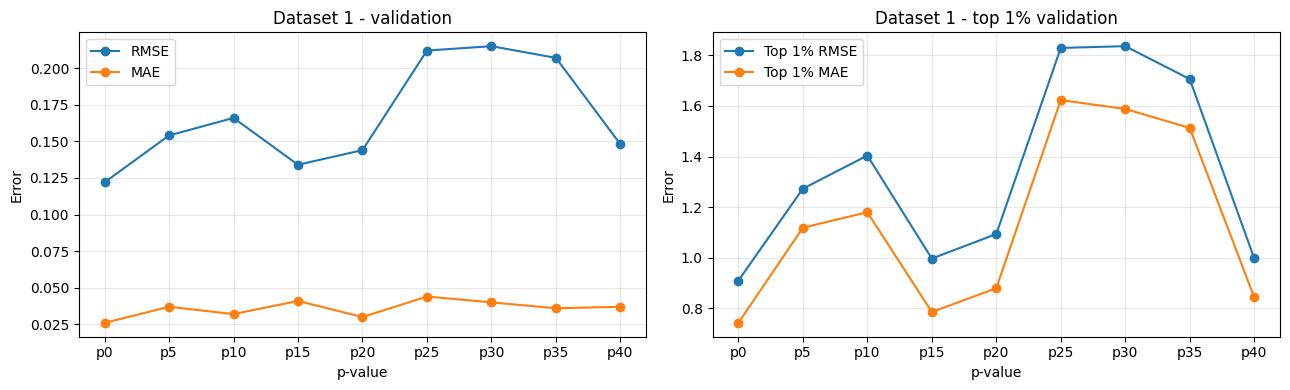

,p_value,experiment,model,validation_rmse,validation_mae,validation_top1_rmse,validation_top1_mae
0,p0,dataset1_temporal_train_05a_specs,MLP (tuned),0.122,0.026,0.910,0.743
8,p5,dataset1_temporal_train_05a_specs,MLP (tuned),0.154,0.037,1.273,1.119
1,p10,dataset1_temporal_train_05a_specs,MLP (tuned),0.166,0.032,1.404,1.180
2,p15,dataset1_temporal_train_05a_specs,MLP (tuned),0.134,0.041,0.997,0.786
3,p20,dataset1_temporal_train_05a_specs,MLP (tuned),0.144,0.030,1.094,0.880
4,p25,dataset1_temporal_train_05a_specs,MLP (tuned),0.212,0.044,1.829,1.623
5,p30,dataset1_temporal_train_05a_specs,MLP (tuned),0.215,0.040,1.836,1.588
6,p35,dataset1_temporal_train_05a_specs,MLP (tuned),0.207,0.036,1.706,1.513
7,p40,dataset1_temporal_train_05a_specs,MLP (tuned),0.148,0.037,0.998,0.844


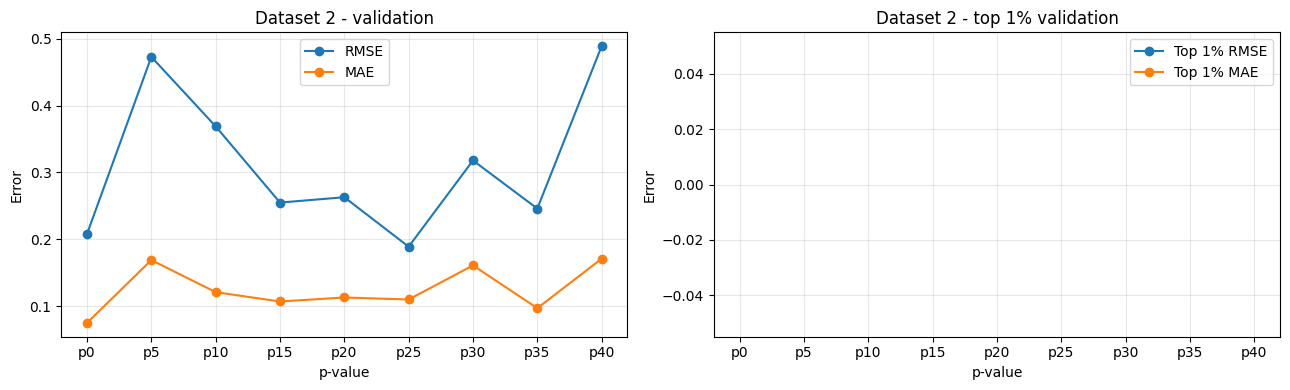

,p_value,experiment,model,validation_rmse,validation_mae,validation_top1_rmse,validation_top1_mae
0,p0,dataset2_random_train_05a_specs,MLP (tuned),0.208,0.075,NaN,NaN
8,p5,dataset2_random_train_05a_specs,MLP (tuned),0.473,0.169,NaN,NaN
1,p10,dataset2_random_train_05a_specs,MLP (tuned),0.369,0.121,NaN,NaN
2,p15,dataset2_random_train_05a_specs,MLP (tuned),0.255,0.107,NaN,NaN
3,p20,dataset2_random_train_05a_specs,MLP (tuned),0.263,0.113,NaN,NaN
4,p25,dataset2_random_train_05a_specs,MLP (tuned),0.189,0.110,NaN,NaN
5,p30,dataset2_random_train_05a_specs,MLP (tuned),0.318,0.161,NaN,NaN
6,p35,dataset2_random_train_05a_specs,MLP (tuned),0.246,0.097,NaN,NaN
7,p40,dataset2_random_train_05a_specs,MLP (tuned),0.489,0.171,NaN,NaN


In [24]:
def prepare_p_plot_data(results_df, dataset_prefix):
    baseline_name = f'{dataset_prefix}_baseline'
    is_baseline = results_df['dataset'].eq(baseline_name)
    is_p_value = results_df['dataset'].str.startswith(f'{dataset_prefix}_p')
    plot_df = results_df[is_baseline | is_p_value].copy()

    plot_df['p_value'] = plot_df['dataset'].str.extract(r'_(p\d+)$')[0]
    plot_df.loc[plot_df['dataset'].eq(baseline_name), 'p_value'] = 'p0'
    plot_df['p_num'] = plot_df['p_value'].str.extract(r'p(\d+)').astype(int)

    # Keep the best saved-model result for each p-value by test RMSE.
    best = (
        plot_df.sort_values(['dataset', 'validation_rmse', 'validation_mae'])
        .groupby('dataset', as_index=False)
        .first()
        .sort_values('p_num')
    )
    return best


def plot_p_value_comparison(results_df, dataset_prefix, title):
    best = prepare_p_plot_data(results_df, dataset_prefix)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True)

    axes[0].plot(best['p_value'], best['validation_rmse'], marker='o', label='RMSE')
    axes[0].plot(best['p_value'], best['validation_mae'], marker='o', label='MAE')
    axes[0].set_title(f'{title} - validation')
    axes[0].set_xlabel('p-value')
    axes[0].set_ylabel('Error')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(best['p_value'], best['validation_top1_rmse'], marker='o', label='Top 1% RMSE')
    axes[1].plot(best['p_value'], best['validation_top1_mae'], marker='o', label='Top 1% MAE')
    axes[1].set_title(f'{title} - top 1% validation')
    axes[1].set_xlabel('p-value')
    axes[1].set_ylabel('Error')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    fig.tight_layout()
    plt.show()

    display_cols = [
        'p_value', 'experiment', 'model',
        'validation_rmse', 'validation_mae', 'validation_top1_rmse', 'validation_top1_mae',
    ]
    display(best[display_cols])


plot_p_value_comparison(results, 'dataset1', 'Dataset 1')
plot_p_value_comparison(results, 'dataset2', 'Dataset 2')